<a href="https://colab.research.google.com/github/Arrah28/AWS-ML-Financial-Health-Analytics-Project/blob/main/Supervised_Stroke_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

#Supervised Data Summary

---







In [4]:
#Loads the datasets into Collab
stroke_df = pd.read_csv('/content/healthcare-dataset-stroke-data.csv')
print ('Print Databases loaded successfully')

Print Databases loaded successfully


In [5]:
# STROKE DATASET SUMMARY
print("--- DATASET OVERVIEW ---")
print(f"Rows: {stroke_df.shape[0]}, Columns: {stroke_df.shape[1]}")
print("\nDescriptive Statistics:\n", stroke_df[['age', 'avg_glucose_level', 'bmi']].describe()) #Count, Mean, Std Dev, Min, 25%, 50% (Median), 75%, and Max
print("\nMissing Values:\n", stroke_df.isnull().sum()) #the is .isnull checks every single cell for a "NaN" then counts missing values


--- DATASET OVERVIEW ---
Rows: 5110, Columns: 12

Descriptive Statistics:
                age  avg_glucose_level          bmi
count  5110.000000        5110.000000  4909.000000
mean     43.226614         106.147677    28.893237
std      22.612647          45.283560     7.854067
min       0.080000          55.120000    10.300000
25%      25.000000          77.245000    23.500000
50%      45.000000          91.885000    28.100000
75%      61.000000         114.090000    33.100000
max      82.000000         271.740000    97.600000

Missing Values:
 id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In the above code, the dataset was first analysed by printing the quantity of data to identify the scale, and then identifying the 201 'missing' values, which identified the data quality issues. Lastly, retrieving  all the mathematical statistics to identify key information and outliers in the dataset, as well as the distribution and range of the features

#So, taking a deeper dive into the results, we can see that:

A total count of 5110 (number of people), and we can
See a discrepancy here, as the BMI count is only 4909, which tells us we are missing data for 201 individuals.  

Our average age range, which is calculated via the mean, is 43 years of age.

Our STD (standard deviation) tells us how spread out the data is, in relation to age and BMI; everyone is close to the average; however, the glucose_level, as expected are very different and spread out.


#Outliers in the data (percentile):

In the BMI column, there is a major difference when comparing the percentiles, especially 75% and Max. This big jump tells us that within the dataset theres people who have a considerably high BMI out of the norm, which further down can cause confusion for the ML model.  



In [6]:
#Mean , Mediam and Standard deviations
print("--- STROKE NUMERICAL MEASURES ---")
stats_stroke = stroke_df[['age', 'avg_glucose_level', 'bmi']].agg(['mean', 'median', 'std'])
print(stats_stroke)

--- STROKE NUMERICAL MEASURES ---
              age  avg_glucose_level        bmi
mean    43.226614         106.147677  28.893237
median  45.000000          91.885000  28.100000
std     22.612647          45.283560   7.854067


In [7]:
# --- CATEGORICAL DISTRIBUTION (STROKE) ---
print("--- STROKE CATEGORICAL DATA ---")
print("Work Type Distribution:\n", stroke_df['work_type'].value_counts())
print("\nSmoking Status Distribution:\n", stroke_df['smoking_status'].value_counts())

--- STROKE CATEGORICAL DATA ---
Work Type Distribution:
 work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Smoking Status Distribution:
 smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


##Visualisations: Histogram, Boxplot and Scatter Plot

---

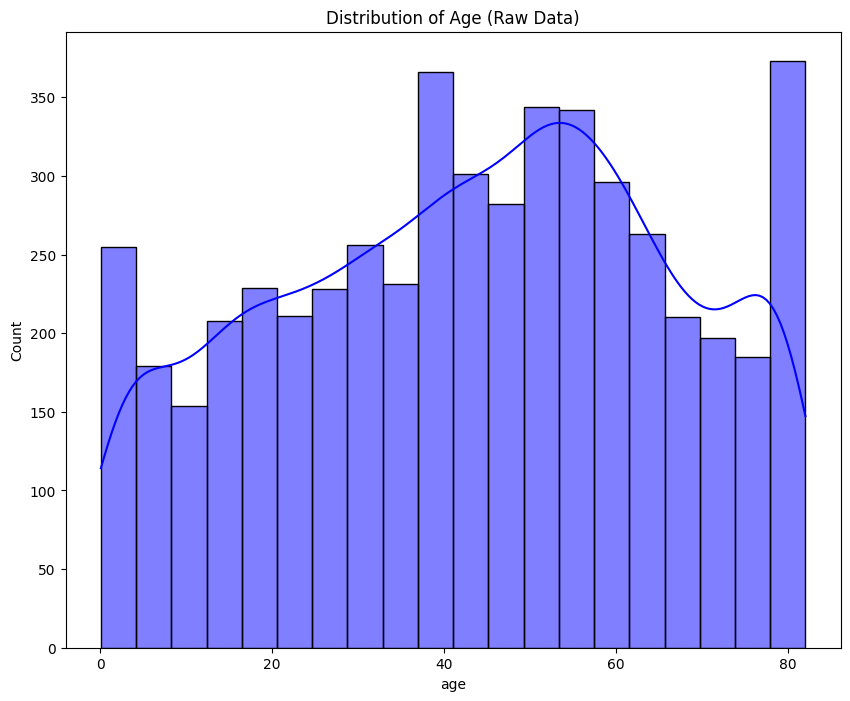

In [8]:
#Histogram is used to check for "Data Distribution" to see if we have a good mix of ages.
plt.figure(figsize=(10, 8))
sns.histplot(stroke_df['age'], kde=True, color='blue')
plt.title('Distribution of Age (Raw Data)')
plt.show()

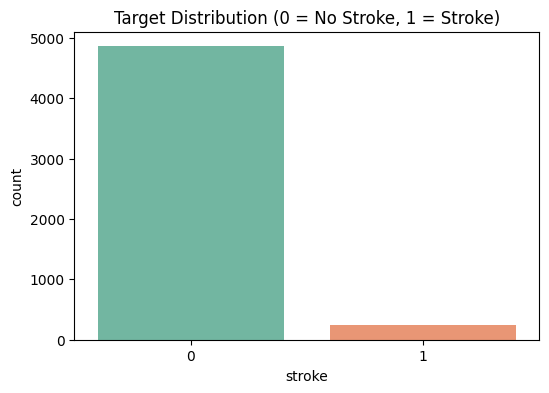

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(x='stroke', data=stroke_df, hue='stroke', palette='Set2', legend=False)
plt.title("Target Distribution (0 = No Stroke, 1 = Stroke)")
plt.show()

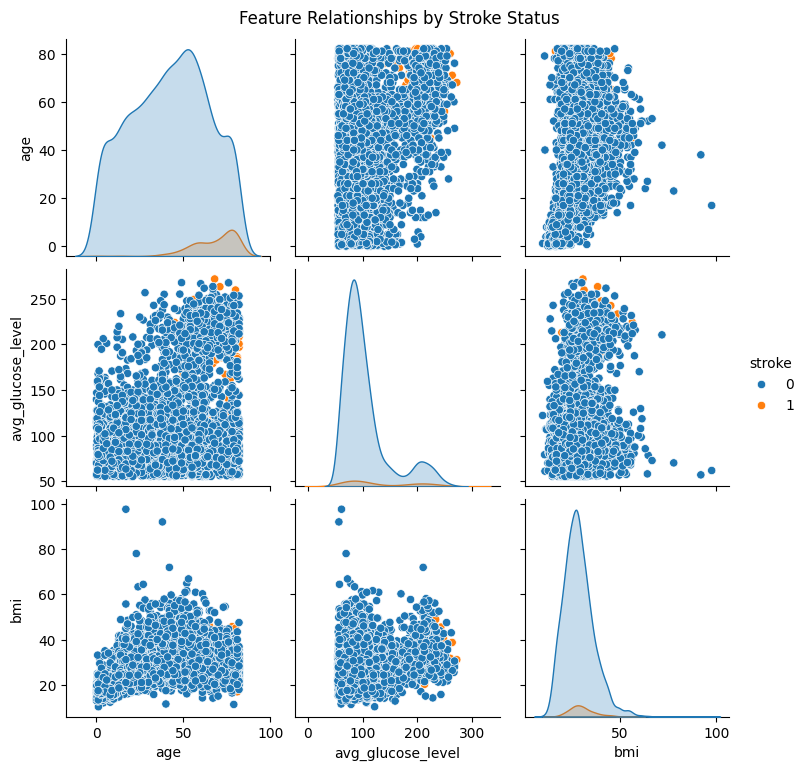

In [10]:
sns.pairplot(stroke_df, hue='stroke', vars=['age', 'avg_glucose_level', 'bmi'])
plt.suptitle("Feature Relationships by Stroke Status", y=1.02)
plt.show()

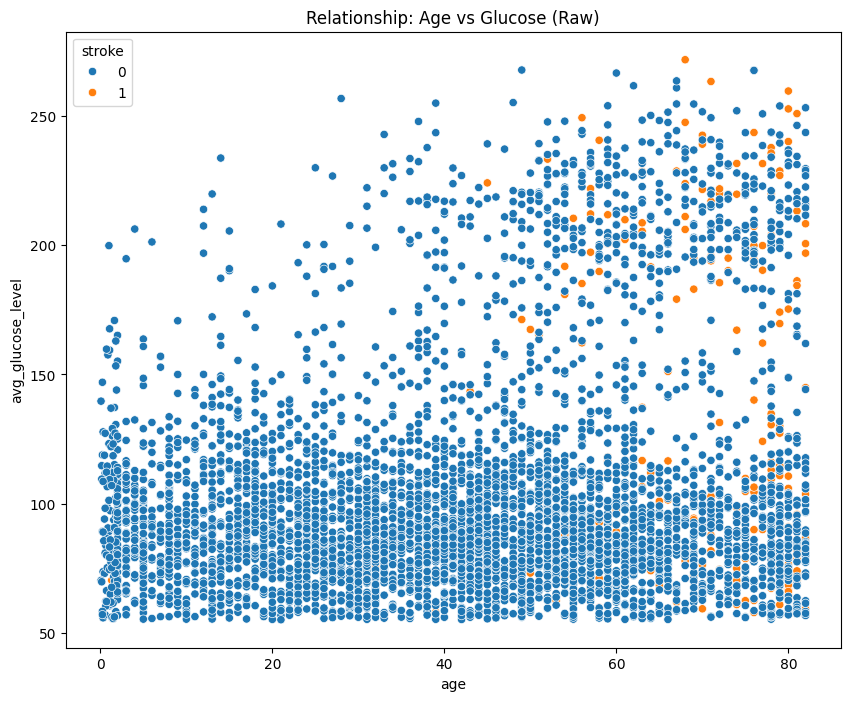

In [11]:
# 3. Scatter Plot: Check for "Relationships" between features , in this case Age and Glucose.
plt.figure(figsize=(10, 8))
sns.scatterplot(data=stroke_df, x='age', y='avg_glucose_level', hue='stroke')
plt.title('Relationship: Age vs Glucose (Raw)')
plt.show()

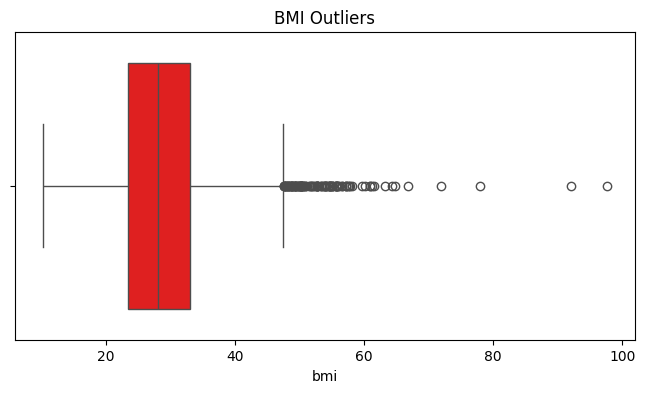

In [12]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='bmi', data=stroke_df, color='red')
plt.title("BMI Outliers")
plt.show()

#Data Pre-processing

---


In [13]:
stroke_df['bmi'] = stroke_df['bmi'].clip(upper=60)

In [14]:
#this will fill the  201 missing BMI values with the median
imputer = SimpleImputer(strategy='median')
stroke_df['bmi'] = imputer.fit_transform(stroke_df[['bmi']])

In [15]:
#Encode categorical features via one hot Encoding
stroke_df_encoded = pd.get_dummies(stroke_df, columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'])

In [16]:
#Standardise the numerical value so the all hav an average of 0 , making the data amore centered and comperable
scaler = StandardScaler()
stroke_df_encoded[['age', 'avg_glucose_level', 'bmi']] = scaler.fit_transform(
    stroke_df_encoded[['age', 'avg_glucose_level', 'bmi']]
)

In [17]:
#Removed the ID column, no vlaue of effect
stroke_df_final = stroke_df_encoded.drop('id', axis=1)

print("Stroke Pre-processing")
stroke_df_final.head()

Stroke Pre-processing


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,ever_married_No,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1.051434,0,1,2.706375,1.026539,1,False,True,False,False,...,False,True,False,False,False,True,False,True,False,False
1,0.786070,0,0,2.121559,-0.097580,1,True,False,False,False,...,False,False,True,False,True,False,False,False,True,False
2,1.626390,0,1,-0.005028,0.484317,1,False,True,False,False,...,False,True,False,False,True,False,False,False,True,False
3,0.255342,0,0,1.437358,0.735590,1,True,False,False,False,...,False,True,False,False,False,True,False,False,False,True
4,1.582163,1,0,1.501184,-0.639802,1,True,False,False,False,...,False,False,True,False,True,False,False,False,True,False


#Test and Train Code Division

---



In [18]:
# Separate the features (X - stroke ) from the target (y - which is what we want to predict,stroke)
X = stroke_df.drop(['id', 'stroke'], axis=1)
y = stroke_df['stroke']
#We will use 80% for training and 20% for testing (0.2)
# stratify=y ensures both sets have the same percentage of strokes.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocessor = make_column_transformer(
    (make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), ['age', 'avg_glucose_level', 'bmi']),
    (OneHotEncoder(handle_unknown='ignore'), ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'])
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 4088 rows
Testing set size: 1022 rows


#Learning Models - Logistic Regression and Random Forest

---



In [19]:
log_reg_pipe = make_pipeline(preprocessor, LogisticRegression(max_iter=1000, class_weight='balanced'))
rf_pipe = make_pipeline(preprocessor, RandomForestClassifier(random_state=42, class_weight='balanced'))

In [20]:
print("Training Logistic Regression...")
log_reg_pipe.fit(X_train, y_train)

Training Logistic Regression...


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['age', 'avg_glucose_level',
                                                   'bmi']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'Residence_type',
                                                   'smoking_status'])])),
                ('logisticregression',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [21]:
print("Training Random Forest...")
rf_pipe.fit(X_train, y_train)

print("\nBoth models have finished learning from the training data.")

Training Random Forest...

Both models have finished learning from the training data.


#Prediction using the trained model

---



In [22]:
y_pred_log = log_reg_pipe.predict(X_test)
y_pred_rf = rf_pipe.predict(X_test)

In [23]:
prediction_results = pd.DataFrame({
    'Actual_Stroke': y_test,
    'LogReg_Prediction': y_pred_log,
    'RandomForest_Prediction': y_pred_rf
})

print("--- Snapshot of Predictions ---")
print(prediction_results.head(10))

--- Snapshot of Predictions ---
      Actual_Stroke  LogReg_Prediction  RandomForest_Prediction
3725              0                  1                        0
4481              0                  0                        0
1545              0                  0                        0
1820              0                  0                        0
1262              0                  1                        0
3618              0                  0                        0
254               0                  0                        0
628               0                  0                        0
3426              0                  0                        0
2687              0                  0                        0


#EVALUATION

---



In [24]:
def show_performance(y_true, y_pred, model_name):
    print(f"\n--- {model_name} Performance ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f} (Crucial for Stroke)")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")

    # Display the Confusion Matrix (As required by Task 2 Checklist)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()


--- Logistic Regression Performance ---
Accuracy:  0.7436
Recall:    0.7800 (Crucial for Stroke)
F1-Score:  0.2294


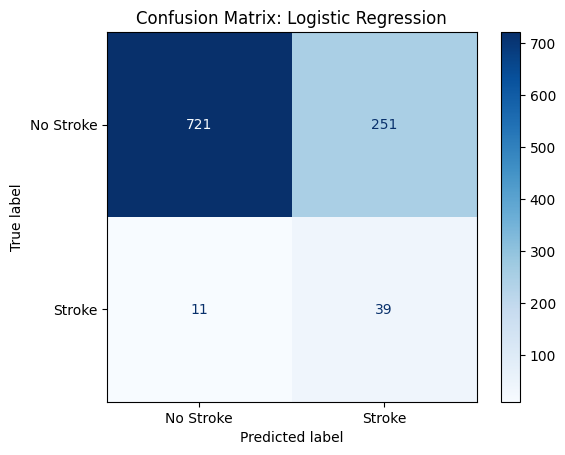


--- Random Forest Performance ---
Accuracy:  0.9481
Recall:    0.0000 (Crucial for Stroke)
F1-Score:  0.0000


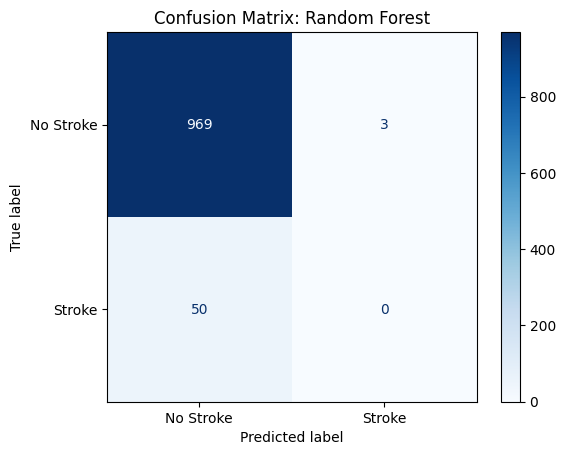

In [25]:
show_performance(y_test, y_pred_log, "Logistic Regression")
show_performance(y_test, y_pred_rf, "Random Forest")